# Capítulos 11 y 12: Series de Fourier y convergencia

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/06-series.ipynb)

Notebook que acompaña a los Capítulos 11 (Series de Fourier) y 12 (Convergencia de la serie de Fourier) de *Introducción al Modelado Continuo*. Reproduce las figuras de los dos capítulos (ondas fundamentales, la señal "sombrero" y sus aproximaciones, el núcleo de Dirichlet, la función signo, $t^2$ y el diente de sierra con sus sumas parciales y el fenómeno de Gibbs) y verifica numéricamente lo que el texto afirma: la ortogonalidad de las $e_k$, las series explícitas del signo y de $t^2$ (con las sumas $\pi/4$ y $\pi^2/12$), la relación $c_k(f') = \frac{2k\pi i}{L}c_k(f)$, el decaimiento de los coeficientes según la regularidad, la identidad de Plancherel y el sobreimpulso de Gibbs ($\approx 9\%$ del salto).

El problema conductor de la Parte II es la **temperatura horaria** de una estación meteorológica: la miramos al principio y volvemos a ella al final del Capítulo 11, escribiéndola como suma de un ciclo anual y un ciclo diario.

Los coeficientes $c_k = \frac1L\int_0^L f(t)e^{-i\omega_k t}\,dt$ se calculan aproximando la integral por la suma de Riemann $\langle f, e_k\rangle_n = \frac1n\sum_j f(t_j)\,\overline{e_k(t_j)}$ sobre una grilla uniforme del período (la misma que motiva el producto interno en la Sección 11.3); eso está en `espectro.coeficientes`, `espectro.coeficientes_reales` y `espectro.suma_parcial`. Cada figura de las notas sale de una celda marcada con su nombre de archivo.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from imc import estilo, espectro, datos
from imc.estilo import COLORES, CICLO
from imc.espectro import coeficientes, coeficientes_funcion, coeficientes_reales, suma_parcial

estilo.activar(fuente=14)   # las figuras van a 0.6-0.7\textwidth (~9-11 cm): fuente grande para que se lean impresas
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.8-0.95\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def periodica(f, L):
    '''Extensión L-periódica de una función definida en [-L/2, L/2).'''
    return lambda t: f((t + L / 2) % L - L / 2)


def graficar_sumas_parciales(f, L, Ns, tt, nombre_f, ylabel, figsize=(6.5, 3.4), ylim=None, xlim=None, loc="upper left", nombre=None, lw_f=3.0, ncol=1):
    '''Gráfico de f (en negro) y de sus sumas parciales S_N para N en Ns, sobre los puntos tt.'''
    k, c = coeficientes_funcion(f, L, N=max(Ns))
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(tt, f(tt), color="black", lw=lw_f, label=nombre_f, zorder=1)      # f gruesa por debajo, sumas parciales finas encima
    for N, col in zip(Ns, CICLO):
        m = np.abs(k) <= N
        ax.plot(tt, suma_parcial(k[m], c[m], L, tt), color=col, lw=1.4, label=rf"$N = {N}$", zorder=3)
    ax.set_xlabel("$t$"); ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    ax.set_xlim(*(xlim or (tt[0], tt[-1])))
    ax.legend(loc=loc, fontsize=11, ncol=ncol, columnspacing=1.0, handlelength=1.3)
    if GUARDAR and nombre: estilo.guardar(fig, nombre)
    return fig, ax, (k, c)

## Problema conductor: la señal de temperatura

Temperatura del aire a 2 m cada hora en Aeroparque (Buenos Aires), 2021–2023 (reanálisis ERA5 vía Open-Meteo; ver `datos/README.md`). Nos quedamos con el año 2023: $8760$ valores, $L = 1$ año. *Figura nueva `serie-temperatura`* (la figura pendiente de la Sección "Problema conductor"): el año completo, con las dos oscilaciones superpuestas (anual y diaria) más la variabilidad irregular, y un zoom sobre una semana de enero donde se ve el ciclo diario.

8760 valores horarios en 2023; media 18.24 °C, mínimo -0.2 °C, máximo 37.0 °C, desvío 6.32 °C


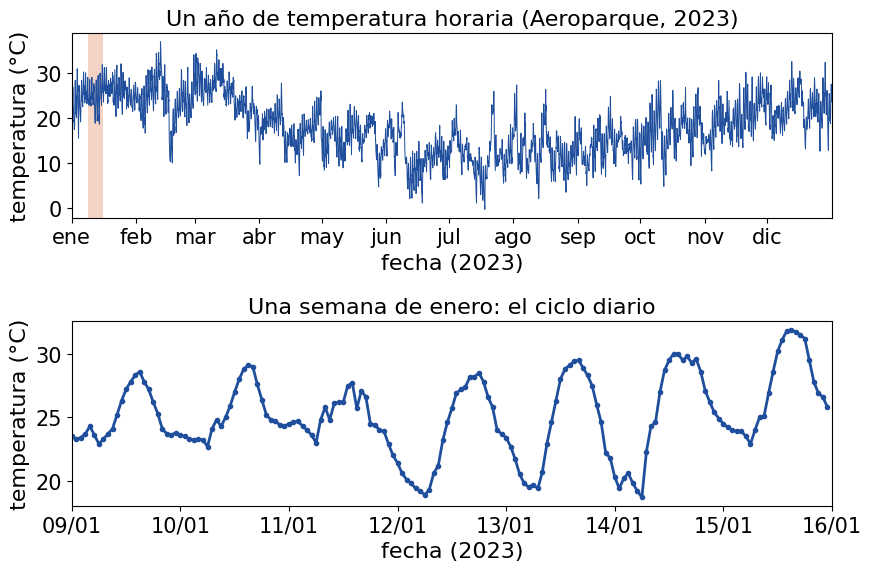

In [2]:
ruta = datos.obtener("temperatura_horaria.csv")
df = pd.read_csv(ruta, parse_dates=["fecha_hora"])
d23 = df[df.fecha_hora.dt.year == 2023].reset_index(drop=True)
T = d23.temp.values                       # T(t_j), t_j = j horas, j = 0..8759
n = len(T); L = 1.0                       # período: 1 año; t en años, t_j = j/8760
t_anio = np.arange(n) / n
print(f"{n} valores horarios en 2023; media {T.mean():.2f} °C, mínimo {T.min():.1f} °C, máximo {T.max():.1f} °C, desvío {T.std():.2f} °C")

semana = (d23.fecha_hora >= "2023-01-09") & (d23.fecha_hora < "2023-01-16")
with fuente(16):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
    ax1.plot(d23.fecha_hora, T, color=COLORES["dato"], lw=0.7)
    ax1.set_ylabel("temperatura (°C)"); ax1.set_title("Un año de temperatura horaria (Aeroparque, 2023)")
    meses = pd.date_range("2023-01-01", "2023-12-01", freq="MS")
    ax1.set_xticks(meses); ax1.set_xticklabels(["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
    ax1.set_xlim(d23.fecha_hora.iloc[0], d23.fecha_hora.iloc[-1]); ax1.set_xlabel("fecha (2023)")
    ax1.axvspan(pd.Timestamp("2023-01-09"), pd.Timestamp("2023-01-16"), color=COLORES["modelo"], alpha=0.25, lw=0)
    ax2.plot(d23.fecha_hora[semana], T[semana], color=COLORES["dato"], lw=2, marker="o", ms=3)
    ax2.set_ylabel("temperatura (°C)"); ax2.set_title("Una semana de enero: el ciclo diario")
    ax2.xaxis.set_major_locator(mdates.DayLocator()); ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax2.set_xlim(pd.Timestamp("2023-01-09"), pd.Timestamp("2023-01-16")); ax2.set_xlabel("fecha (2023)")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "serie-temperatura")

## 11.1 Ondas fundamentales

Una onda fundamental es $A\cos(\omega_0 t + \phi)$ con amplitud $A$, frecuencia angular $\omega_0 = 2\pi f$ y fase $\phi$; el período es $T = 1/f = 2\pi/\omega_0$. **Figura `ondas-fundamentales`**: tres paneles en los que se varía uno solo de los tres parámetros a partir de $A = 1$, $f = 1$, $\phi = 0$. Corrección respecto de la original: cada curva tiene su leyenda con el valor del parámetro.

In [3]:
tt = np.linspace(0, 2, 800)
onda = lambda t, A=1.0, f=1.0, phi=0.0: A * np.cos(2 * np.pi * f * t + phi)
casos = [("Variando la amplitud $A$", [dict(A=0.5), dict(A=1.0), dict(A=1.5)], lambda p: rf"$A = {p['A']}$"),
         ("Variando la frecuencia $f$", [dict(f=0.5), dict(f=1.0), dict(f=2.0)], lambda p: rf"$f = {p['f']}$, $T = {1 / p['f']:g}$"),
         ("Variando la fase $\phi$", [dict(phi=0.0), dict(phi=np.pi / 4), dict(phi=np.pi / 2)], lambda p: rf"$\phi = {p['phi'] / np.pi:g}\pi$" if p['phi'] else r"$\phi = 0$")]
with fuente(18):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
    for ax, (titulo, params, etiqueta) in zip(axs, casos):
        for p, col in zip(params, CICLO):
            ax.plot(tt, onda(tt, **p), color=col, lw=2, label=etiqueta(p))
        ax.axhline(0, color="0.6", lw=0.8, zorder=0)
        ax.set_title(titulo); ax.set_xlabel("$t$"); ax.set_ylim(-1.7, 3.4); ax.set_xticks([0, 0.5, 1, 1.5, 2])
        ax.legend(loc="upper left", ncol=1, handlelength=1.2, columnspacing=0.8)
    axs[0].set_ylabel(r"$A\cos(2\pi f t + \phi)$"); axs[0].set_yticks([-1, 0, 1, 2])
    fig.text(0.5, -0.02, r"En cada panel, los otros dos parámetros valen $A = 1$, $f = 1$ ($T = 1$), $\phi = 0$.", ha="center", fontsize=15)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "ondas-fundamentales")

## 11.2 Superposición de ondas fundamentales: la señal "sombrero"

Una señal de período $L = 1$: un triángulo de altura $1/4$ centrado en $t = 1/2$ y de base $[1/3, 2/3]$, extendido periódicamente (**Figura `sombrero`**). Las únicas frecuencias compatibles con la periodicidad son $\omega_k = 2k\pi/L$, y buscamos $f(t)\sim\sum_k c_k e^{i\omega_k t}$. **Figura `sombrero-aproximacion`**: las sumas parciales $S_N[f] = \sum_{|k|\le N} c_k e^{i\omega_k t}$ con $N = 1, 3, 8$ frecuencias (los $c_k$ se calculan con la fórmula de la Sección 11.4, que en este punto del texto todavía no vimos: acá sólo los usamos).

In [4]:
L_s = 1.0
sombrero = lambda t: np.maximum(0.0, 0.25 - 1.5 * np.abs((t % L_s) - 0.5))
tt = np.linspace(0, 3, 1500)

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(tt, sombrero(tt), color=COLORES["dato"], lw=2.2)
ax.set_xlabel("$t$"); ax.set_ylabel("$f(t)$"); ax.set_xlim(0, 3); ax.set_yticks([0, 0.1, 0.2])
estilo.parametros(ax, "período $L = 1$", loc="upper right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "sombrero")

fig, ax, (k, c) = graficar_sumas_parciales(sombrero, L_s, [1, 3, 8], tt, "señal $f(t)$", "$f(t)$", figsize=(6.5, 3.6), ylim=(-0.06, 0.34), loc="upper left", nombre="sombrero-aproximacion", ncol=4)
print("coeficientes c_k del sombrero, k = 0..8:", np.round(c[k >= 0][:9].real, 5), " (parte imaginaria máxima:", f"{np.abs(c.imag).max():.1e})")

coeficientes c_k del sombrero, k = 0..8: [ 0.04167 -0.038    0.0285  -0.01689  0.00712 -0.00152  0.      -0.00078
  0.00178]  (parte imaginaria máxima: 9.0e-19)


## 11.3–11.4 Ortogonalidad y coeficientes de Fourier

Con el producto interno $\langle f, g\rangle = \frac1L\int_0^L f\,\bar g\,dt$ las ondas $e_k(t) = e^{i\omega_k t}$ son ortonormales, y $\{1, \cos(\omega_k t), \sin(\omega_k t)\}$ es ortogonal con $\langle\cos_k, \cos_k\rangle = \langle\sin_k,\sin_k\rangle = 1/2$. Lo verificamos con la versión discreta $\langle f, g\rangle_n = \frac1n\sum_j f(t_j)\overline{g(t_j)}$ sobre $n$ puntos del período (que es lo que usa `espectro.coeficientes`): para $n$ grande da exactamente lo mismo que la integral.

In [5]:
L = 2.0; n = 400
tj = np.arange(n) * L / n
ks = np.arange(-4, 5)
E = np.exp(2j * np.pi * np.outer(ks, tj) / L)              # E[k, j] = e_k(t_j)
G = E @ E.conj().T / n                                    # G[k, m] = <e_k, e_m>_n
print("max |<e_k, e_m>_n - delta_km| para |k|, |m| <= 4, n =", n, ":", f"{np.abs(G - np.eye(len(ks))).max():.1e}")
C = np.cos(2 * np.pi * np.outer(ks[ks > 0], tj) / L); S = np.sin(2 * np.pi * np.outer(ks[ks > 0], tj) / L)
print("<cos_k, cos_m>_n:\n", np.round(C @ C.T / n, 12)[:3, :3], "\n<sin_k, cos_m>_n: max", f"{np.abs(S @ C.T / n).max():.1e}", "  <sin_k, sin_k>_n:", np.round(np.diag(S @ S.T / n), 12)[:3])
# la misma cuenta con la integral (regla del trapecio fina) para un par de funciones
tf = np.linspace(0, L, 20001)
print("(1/L) int_0^L cos(w_2 t) cos(w_2 t) dt =", f"{np.trapezoid(np.cos(2 * np.pi * 2 * tf / L) ** 2, tf) / L:.6f}", ";  con k = 2, m = 3:", f"{np.trapezoid(np.cos(2 * np.pi * 2 * tf / L) * np.cos(2 * np.pi * 3 * tf / L), tf) / L:.1e}")

max |<e_k, e_m>_n - delta_km| para |k|, |m| <= 4, n = 400 : 2.2e-16
<cos_k, cos_m>_n:
 [[ 0.5 -0.  -0. ]
 [-0.   0.5 -0. ]
 [-0.  -0.   0.5]] 
<sin_k, cos_m>_n: max 2.8e-17   <sin_k, sin_k>_n: [0.5 0.5 0.5]
(1/L) int_0^L cos(w_2 t) cos(w_2 t) dt = 0.500000 ;  con k = 2, m = 3: -2.8e-17


## 11.5 Serie de Fourier real. Volvemos a la señal de temperatura

Para una señal real, $c_{-k} = \overline{c_k}$ y la serie se reescribe como $\frac{a_0}{2} + \sum_{k\ge1} a_k\cos(\omega_k t) + b_k\sin(\omega_k t)$ con $a_k = 2\,\Re c_k$, $b_k = -2\,\Im c_k$; cada término es una onda fundamental de amplitud $A_k = \sqrt{a_k^2 + b_k^2}$ y fase $\phi_k$ con $\tan\phi_k = -b_k/a_k$ (es decir $c_k = \frac{A_k}{2}e^{i\phi_k}$).

Tomamos $T(t)$ de período $L = 1$ año: la componente $k$ tiene frecuencia $k$ ciclos por año, $k = 1$ es el ciclo anual y $k = 365$ el diario. El texto afirma que $\phi_1$ dice en qué día del año se alcanza la temperatura máxima media y $A_1$ cuánto difiere ese máximo de la media anual $a_0/2$. *Figura nueva `temperatura-serie-fourier`*: arriba, el espectro de amplitudes $A_k$; abajo, dos semanas de la señal y la reconstrucción con **sólo** la media, $k = 1$, $k = 365$ y $k = 730$ (cuatro números complejos en lugar de $8760$ valores). Con la identidad de Plancherel del Capítulo 12, $\frac1L\int_0^L |T - \bar T|^2 = \sum_{k\ne0}|c_k|^2 = \sum_{k\ge1} A_k^2/2$, medimos qué fracción de la varianza explican esos pocos términos.

In [6]:
k_T, a, b = coeficientes_reales(T, L=1.0)            # k = 0..4379 ciclos por año
A = np.sqrt(a**2 + b**2); phi = np.arctan2(-b, a)     # A_k, phi_k  (tan phi_k = -b_k / a_k)
media = a[0] / 2
dia_max = ((-phi[1] / (2 * np.pi)) % 1) * 365          # máximo de cos(2 pi t + phi_1): t = -phi_1 / (2 pi) años
hora_max = ((-phi[365] / (2 * np.pi)) % 1) * 24        # ídem para k = 365: t = -phi/(2 pi) días
fecha_max = pd.Timestamp("2023-01-01") + pd.Timedelta(days=dia_max)
print(f"media anual a_0/2 = {media:.2f} °C")
print(f"ciclo anual  (k = 1):   A_1 = {A[1]:.2f} °C, phi_1 = {phi[1]:+.3f} rad -> máximo el día {dia_max:.0f} del año ({fecha_max:%d/%m}); "
      f"máximo medio = {media + A[1]:.1f} °C, mínimo medio = {media - A[1]:.1f} °C")
print(f"ciclo diario (k = 365): A_365 = {A[365]:.2f} °C, phi_365 = {phi[365]:+.3f} rad -> máximo a las {int(hora_max)}:{int(60 * (hora_max % 1)):02d} h")
print(f"k = 730 (12 h): A_730 = {A[730]:.2f} °C;  k = 2 (semestral): A_2 = {A[2]:.2f} °C")
var = np.mean((T - media) ** 2)
print(f"\nPlancherel: varianza {var:.3f} = suma A_k^2/2 {np.sum(A[1:] ** 2 / 2):.3f}")
for ks in ([1], [1, 365], [1, 365, 730], [1, 2, 365, 730]):
    print(f"   k en {ks}: {100 * sum(A[k] ** 2 / 2 for k in ks) / var:.1f}% de la varianza")
xi_, A_, phi_ = espectro.amplitudes(T, dt=1 / n)      # la misma cuenta con espectro.amplitudes
print("\ncoincide con espectro.amplitudes:", np.allclose(A_[1:len(A)], A[1:]), np.allclose(phi_[1:len(A)], phi[1:]))

modos = [0, 1, 365, 730]
recon = media + sum(A[k] * np.cos(2 * np.pi * k * t_anio + phi[k]) for k in modos[1:])
recon_anual = media + A[1] * np.cos(2 * np.pi * t_anio + phi[1])
dos_sem = (d23.fecha_hora >= "2023-01-09") & (d23.fecha_hora < "2023-01-23")
with fuente(16):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
    kmax = 1500
    ax1.semilogy(k_T[1:kmax + 1], A[1:kmax + 1], color=COLORES["dato"], lw=0.8)
    for k, txt, dx in [(1, "$k=1$: anual", 6), (365, "$k=365$: diario", 0), (730, "$k=730$: 12 h", 0)]:
        ax1.plot(k, A[k], "o", color=COLORES["modelo"], ms=8, zorder=5)
        ax1.annotate(txt, (k, A[k]), (dx + 12, 8), textcoords="offset points", fontsize=14, color=COLORES["modelo"])
    ax1.set_xlabel("$k$ (ciclos por año)"); ax1.set_ylabel("$A_k$ (°C)"); ax1.set_xlim(-25, kmax); ax1.set_ylim(1e-2, 20)
    ax1.set_title("Amplitudes de la serie de Fourier real de la temperatura (2023, $L = 1$ año)")
    ax2.plot(d23.fecha_hora[dos_sem], T[dos_sem], color=COLORES["dato"], lw=1.2, label="temperatura")
    ax2.plot(d23.fecha_hora[dos_sem], recon[dos_sem], color=COLORES["modelo"], lw=2.2, label="media + $k = 1, 365, 730$")
    ax2.plot(d23.fecha_hora[dos_sem], recon_anual[dos_sem], color=COLORES["nul_p"], lw=2, ls="--", label="media + $k = 1$")
    ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2)); ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax2.set_xlim(pd.Timestamp("2023-01-09"), pd.Timestamp("2023-01-23")); ax2.set_ylabel("temperatura (°C)"); ax2.set_ylim(14, 37); ax2.set_xlabel("fecha (2023)")
    ax2.legend(loc="upper left", ncol=3); ax2.set_title("Dos semanas de enero y la reconstrucción con cuatro términos")
    estilo.parametros(ax2, rf"$a_0/2 = {media:.1f}$, $A_1 = {A[1]:.1f}$, $A_{{365}} = {A[365]:.1f}$ (°C)", loc="lower right", fontsize=13)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "temperatura-serie-fourier")

media anual a_0/2 = 18.24 °C
ciclo anual  (k = 1):   A_1 = 6.92 °C, phi_1 = -0.419 rad -> máximo el día 24 del año (25/01); máximo medio = 25.2 °C, mínimo medio = 11.3 °C
ciclo diario (k = 365): A_365 = 2.76 °C, phi_365 = +2.164 rad -> máximo a las 15:44 h
k = 730 (12 h): A_730 = 0.83 °C;  k = 2 (semestral): A_2 = 0.80 °C

Plancherel: varianza 39.946 = suma A_k^2/2 39.946
   k en [1]: 59.9% de la varianza
   k en [1, 365]: 69.4% de la varianza
   k en [1, 365, 730]: 70.2% de la varianza
   k en [1, 2, 365, 730]: 71.0% de la varianza

coincide con espectro.amplitudes: True True


## 12.1 Propiedades de los coeficientes de Fourier

Proposición 12.1: (1) $|c_k|\le\frac1L\int_0^L|f|$; (3) si $f$ es continua y $C^1$ a trozos, $c_k(f') = \frac{2k\pi i}{L}c_k(f)$; (4)–(5) si $f$ es real y par los $c_k$ son reales, si es impar son imaginarios puros. Verificamos (3) con la función suave $f(t) = e^{\sin(2\pi t)}$ ($L = 1$) y (4)–(5) con $t^2$ y $\operatorname{sg}(t)$ en $[-1,1]$.

De (1) y (3) sale que los coeficientes decaen tanto más rápido cuanto más regular es $f$: $|c_k|\le C/k$ si $f$ es continua con $f'$ integrable, $|c_k|\le C/k^2$ si además $f'$ es continua con $f''$ integrable, y así siguiendo; una función con un salto sólo tiene $c_k\to0$ (Riemann–Lebesgue), en general como $1/k$. *Figura nueva `decaimiento-coeficientes`*: $|c_k|$ en escala log-log para el signo (salto: $|c_k| = \frac{2}{k\pi}$ para $k$ impar), para $t^2$ (continua con un quiebre: $|c_k| = \frac{2}{k^2\pi^2}$) y para $e^{\sin(2\pi t)}$ ($C^\infty$: decaimiento más rápido que cualquier potencia; sus coeficientes están por debajo de $10^{-16}$, la precisión de la máquina, a partir de $k \approx 18$).

In [7]:
suave = lambda t: np.exp(np.sin(2 * np.pi * t))
suave_d = lambda t: 2 * np.pi * np.cos(2 * np.pi * t) * suave(t)
ks, cf = coeficientes_funcion(suave, 1.0, N=12); _, cfd = coeficientes_funcion(suave_d, 1.0, N=12)
m = ks != 0
print("max |c_k(f') - (2 k pi i / L) c_k(f)| / |c_k(f')|, 1 <= |k| <= 12:", f"{np.max(np.abs(cfd[m] - 2j * np.pi * ks[m] * cf[m]) / np.abs(cfd[m])):.1e}")
print("cota (1): max |c_k| =", f"{np.abs(cf).max():.4f}", " <=  (1/L) int |f| =", f"{np.mean(suave(np.linspace(0, 1, 100001))):.4f}")

L = 2.0
signo = lambda t: np.sign(np.round(np.sin(np.pi * t), 12))   # sg(t) en [-1, 1], extendida con período 2 (vale 0 en los saltos)
cuadr = periodica(lambda t: t**2, L)
diente = periodica(lambda t: t, L)
K, c_sg = coeficientes_funcion(signo, L, N=2000); _, c_t2 = coeficientes_funcion(cuadr, L, N=2000)   # |k| <= 2000
print(f"signo (impar): max |Re c_k| = {np.abs(c_sg.real).max():.1e};   t^2 (par): max |Im c_k| = {np.abs(c_t2.imag).max():.1e}")
kp = K[K > 0]; impar = kp % 2 == 1
print("signo: max error relativo de |c_k| respecto de 2/(k pi) (k impar <= 200):", f"{np.max(np.abs(np.abs(c_sg[K > 0][impar][:100]) * kp[impar][:100] * np.pi / 2 - 1)):.1e}")
print("t^2:   max error relativo de |c_k| respecto de 2/(k^2 pi^2) (k <= 200):     ", f"{np.max(np.abs(np.abs(c_t2[K > 0][:200]) * kp[:200] ** 2 * np.pi ** 2 / 2 - 1)):.1e}")

max |c_k(f') - (2 k pi i / L) c_k(f)| / |c_k(f')|, 1 <= |k| <= 12: 6.7e-06
cota (1): max |c_k| = 1.2661  <=  (1/L) int |f| = 1.2661
signo (impar): max |Re c_k| = 1.6e-17;   t^2 (par): max |Im c_k| = 7.3e-18
signo: max error relativo de |c_k| respecto de 2/(k pi) (k impar <= 200): 3.0e-05
t^2:   max error relativo de |c_k| respecto de 2/(k^2 pi^2) (k <= 200):      3.1e-05


*Figura nueva `decaimiento-coeficientes`*: $|c_k|$ contra $k$ en escala log-log para las tres funciones, con las rectas de referencia $k^{-1}$ y $k^{-2}$. La pendiente en el gráfico log-log es el orden de decaimiento, que es a su vez el grado de regularidad de $f$: salto $\to k^{-1}$, quiebre $\to k^{-2}$, $C^\infty\to$ más rápido que cualquier potencia.

In [8]:
k1, c1 = coeficientes_funcion(suave, 1.0, N=40)
fig, ax = plt.subplots(figsize=(6, 4.4))
ax.loglog(kp[impar], np.abs(c_sg[K > 0][impar]), ".", ms=5, color=CICLO[0], label=r"$\mathrm{sg}(t)$ (salto)")
ax.loglog(kp, np.abs(c_t2[K > 0]), ".", ms=5, color=CICLO[1], label=r"$t^2$ (continua, con quiebre)")
ax.loglog(k1[k1 > 0], np.clip(np.abs(c1[k1 > 0]), 1e-17, None), ".", ms=6, color=CICLO[2], label=r"$e^{\,\mathrm{sen}(2\pi t)}$ ($C^\infty$)")
ax.loglog(kp, 1 / kp, "--", color="0.4", lw=1.2); ax.loglog(kp, 1 / kp**2, ":", color="0.4", lw=1.5)
ax.text(300, 1 / 300 * 1.8, "$k^{-1}$", fontsize=13, color="0.3"); ax.text(300, 1 / 300**2 * 2.5, "$k^{-2}$", fontsize=13, color="0.3")
ax.set_xlabel("$k$"); ax.set_ylabel("$|c_k|$"); ax.set_ylim(3e-18, 3); ax.set_xlim(0.8, 2500)
ax.legend(loc="center right", bbox_to_anchor=(0.99, 0.42), fontsize=11)
if GUARDAR: estilo.guardar(fig, "decaimiento-coeficientes")

## 12.2 Convergencia puntual: el núcleo de Dirichlet

La suma parcial es una convolución con el núcleo de Dirichlet: $S_N[f](t) = \int_{-L/2}^{L/2} f(s)D_N(t-s)\,ds$ con
$$D_N(t) = \frac1L\sum_{k=-N}^N e^{i\omega_k t} = \frac1L\,\frac{\sin\bigl(\frac{2\pi}{L}(N+\tfrac12)t\bigr)}{\sin\bigl(\frac{\pi}{L}t\bigr)},$$
que es $L$-periódico, par, con $\int_{-L/2}^{L/2}D_N = 1$ y $D_N(0) = \frac{2N+1}{L}$. **Figura `nucleo-dirichlet`**: $N = 10$, $L = 2\pi$. Corrección: la figura original mostraba $\sum_k e^{i\omega_k t}$ sin el factor $1/L$ (con $D_N(0) = 21$); ahora incluye el $1/L$ de la definición del texto, de modo que $D_N(0) = 21/(2\pi)\approx 3.34$ y el área bajo la curva es $1$.

In [9]:
def dirichlet(t, N, L):
    '''Núcleo de Dirichlet D_N(t) = (1/L) sum_{|k|<=N} e^{i w_k t} = (1/L) sen(2 pi (N+1/2) t/L) / sen(pi t/L).'''
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        D = np.sin(2 * np.pi * (N + 0.5) * t / L) / np.sin(np.pi * t / L) / L
    return np.where(np.isclose(np.sin(np.pi * t / L), 0), (2 * N + 1) / L, D)

N, L_D = 10, 2 * np.pi
tt = np.linspace(-L_D / 2, L_D / 2, 4001)
suma = sum(np.exp(2j * np.pi * k * tt / L_D) for k in range(-N, N + 1)).real / L_D
print(f"N = {N}, L = 2 pi: max |D_N - (1/L) sum e^(i w_k t)| = {np.abs(dirichlet(tt, N, L_D) - suma).max():.1e};  D_N(0) = {dirichlet(0.0, N, L_D):.4f} = (2N+1)/L = {(2 * N + 1) / L_D:.4f}")
print(f"int_(-L/2)^(L/2) D_N = {np.trapezoid(dirichlet(tt, N, L_D), tt):.6f};   int_0^(L/2) D_N = {np.trapezoid(dirichlet(tt[tt >= 0], N, L_D), tt[tt >= 0]):.6f};   D_N(-t) = D_N(t): {np.allclose(dirichlet(tt, N, L_D), dirichlet(-tt, N, L_D))}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tt, dirichlet(tt, N, L_D), color=COLORES["dato"], lw=2)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("$t$"); ax.set_ylabel("$D_N(t)$"); ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]); ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "$0$", r"$\pi/2$", r"$\pi$"])
estilo.parametros(ax, rf"$N = {N}$, $L = 2\pi$" + "\n" + rf"$D_N(0) = \frac{{2N+1}}{{L}} \approx {(2 * N + 1) / L_D:.2f}$", loc="upper right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "nucleo-dirichlet")

N = 10, L = 2 pi: max |D_N - (1/L) sum e^(i w_k t)| = 3.3e-15;  D_N(0) = 3.3423 = (2N+1)/L = 3.3423
int_(-L/2)^(L/2) D_N = 1.000000;   int_0^(L/2) D_N = 0.500000;   D_N(-t) = D_N(t): True


### Ejemplo: la función signo

$\operatorname{sg}(t)$ en $[-1,1]$ extendida con período $L = 2$ (**Figura `signo`**). Es real e impar, así que su serie es de senos: $\operatorname{sg}(t) = \frac4\pi\sum_{k\ge0}\frac{\sin((2k+1)\pi t)}{2k+1}$. **Figura `signo-aproximacion`**: sumas parciales $S_N$ para $N = 1, 3, 5, 15$ (Dini: en cada punto de continuidad convergen a $\operatorname{sg}(t)$, y en los saltos al promedio $0$). Evaluando en $t = 1/2$ se obtiene $\frac\pi4 = 1 - \frac13 + \frac15 - \cdots$.

In [10]:
tt = np.linspace(-3, 3, 6001)
fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(tt, signo(tt), color=COLORES["dato"], lw=2.2)
ax.set_xlabel("$t$"); ax.set_ylabel(r"$\mathrm{sg}(t)$"); ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 1.5)
estilo.parametros(ax, "período $L = 2$", loc="upper right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "signo")

graficar_sumas_parciales(signo, L, [1, 3, 5, 15], tt, r"$\mathrm{sg}(t)$", r"$\mathrm{sg}(t)$", ylim=(-1.6, 2.2), loc="upper left", nombre="signo-aproximacion", ncol=5)

# a_k = 2 Re c_k = 0, b_k = -2 Im c_k = 4/(k pi) para k impar;  serie en t = 1/2
kk, a_sg, b_sg = coeficientes_reales(signo(np.arange(2**16) * L / 2**16), L, N=15)
print("b_k, k = 1..7:", np.round(b_sg[1:8], 5), " (texto: 4/(k pi) =", np.round([4 / (kq * np.pi) if kq % 2 else 0 for kq in range(1, 8)], 5), ")")
for N in [15, 100, 1000, 100000]:
    kq = np.arange(N + 1)
    print(f"N = {N:6d}: 4/pi * sum_(k<=N) (-1)^k/(2k+1) = {4 / np.pi * np.sum((-1.0) ** kq / (2 * kq + 1)):.6f}   (sg(1/2) = 1)")

b_k, k = 1..7: [ 1.27324 -0.       0.42441 -0.       0.25465 -0.       0.18189]  (texto: 4/(k pi) = [1.27324 0.      0.42441 0.      0.25465 0.      0.18189] )
N =     15: 4/pi * sum_(k<=N) (-1)^k/(2k+1) = 0.980125   (sg(1/2) = 1)
N =    100: 4/pi * sum_(k<=N) (-1)^k/(2k+1) = 1.003152   (sg(1/2) = 1)
N =   1000: 4/pi * sum_(k<=N) (-1)^k/(2k+1) = 1.000318   (sg(1/2) = 1)
N = 100000: 4/pi * sum_(k<=N) (-1)^k/(2k+1) = 1.000003   (sg(1/2) = 1)


### Ejemplo: $f(t) = t^2$ en $[-1,1]$

Extendida con período $2$ es continua, con quiebres en $t = \pm1$ (**Figura `cuadratica`**). Es par: serie de cosenos, $t^2 = \frac13 + \frac4{\pi^2}\sum_{k\ge1}\frac{(-1)^k}{k^2}\cos(k\pi t)$; en $t = 0$ da $\frac{\pi^2}{12} = 1 - \frac14 + \frac19 - \cdots$. **Figura `cuadratica-aproximaciones`**: $S_N$ para $N = 1, 3, 5, 15$. Como $|c_k|\le C/k^2$ es sumable, acá la convergencia es **uniforme** (Corolario 12.2 y Proposición 12.3): el error máximo $\sup_t|f - S_N[f]|$ tiende a $0$, cosa que para el signo no pasa (lo vemos abajo).

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(tt, cuadr(tt), color=COLORES["dato"], lw=2.2)
ax.set_xlabel("$t$"); ax.set_ylabel("$f(t)$"); ax.set_xlim(-3, 3); ax.set_ylim(-0.1, 1.15)
estilo.parametros(ax, "$f(t) = t^2$ en $[-1, 1]$, $L = 2$", loc="upper right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "cuadratica")

graficar_sumas_parciales(cuadr, L, [1, 3, 5, 15], tt, "$t^2$ periódica", "$f(t)$", ylim=(-0.15, 1.35), loc="upper left", nombre="cuadratica-aproximaciones", ncol=5)

kk, a_t2, b_t2 = coeficientes_reales(cuadr(np.arange(2**16) * L / 2**16), L, N=15)
print("a_0/2 =", f"{a_t2[0] / 2:.5f}", "(texto: 1/3);  a_k, k = 1..5:", np.round(a_t2[1:6], 5), " (texto: 4 (-1)^k / (k pi)^2 =", np.round([4 * (-1) ** kq / (kq * np.pi) ** 2 for kq in range(1, 6)], 5), ")")
for N in [15, 1000, 100000]:
    kq = np.arange(1, N + 1)
    print(f"N = {N:6d}: sum_(k<=N) (-1)^(k+1)/k^2 = {np.sum((-1.0) ** (kq + 1) / kq ** 2):.6f}   (pi^2/12 = {np.pi ** 2 / 12:.6f})")
print("\nerror máximo sup|f - S_N| (convergencia uniforme) y error cuadrático medio (1/L) int |f - S_N|^2:")
for N in [1, 3, 5, 15, 50, 200]:
    m = np.abs(K) <= N
    e_t2 = cuadr(tt) - suma_parcial(K[m], c_t2[m], L, tt)
    e_sg = signo(tt) - suma_parcial(K[m], c_sg[m], L, tt)
    print(f"N = {N:3d}:   t^2: sup = {np.abs(e_t2).max():.4f}, ecm = {np.mean(e_t2 ** 2):.2e}   |   signo: sup = {np.abs(e_sg).max():.4f}, ecm = {np.mean(e_sg ** 2):.2e}")

a_0/2 = 0.33333 (texto: 1/3);  a_k, k = 1..5: [-0.40528  0.10132 -0.04503  0.02533 -0.01621]  (texto: 4 (-1)^k / (k pi)^2 = [-0.40528  0.10132 -0.04503  0.02533 -0.01621] )
N =     15: sum_(k<=N) (-1)^(k+1)/k^2 = 0.824542   (pi^2/12 = 0.822467)
N =   1000: sum_(k<=N) (-1)^(k+1)/k^2 = 0.822467   (pi^2/12 = 0.822467)
N = 100000: sum_(k<=N) (-1)^(k+1)/k^2 = 0.822467   (pi^2/12 = 0.822467)

error máximo sup|f - S_N| (convergencia uniforme) y error cuadrático medio (1/L) int |f - S_N|^2:
N =   1:   t^2: sup = 0.2614, ecm = 6.77e-03   |   signo: sup = 0.9960, ecm = 1.88e-01
N =   3:   t^2: sup = 0.1150, ecm = 6.16e-04   |   signo: sup = 0.9920, ecm = 9.84e-02
N =   5:   t^2: sup = 0.0735, ecm = 1.63e-04   |   signo: sup = 0.9880, ecm = 6.59e-02
N =  15:   t^2: sup = 0.0261, ecm = 7.46e-06   |   signo: sup = 0.9680, ecm = 2.43e-02
N =  50:   t^2: sup = 0.0080, ecm = 2.26e-07   |   signo: sup = 0.9001, ecm = 7.14e-03
N = 200:   t^2: sup = 0.0020, ecm = 4.74e-09   |   signo: sup = 0.6087, ecm =

## 12.4 Convergencia en media cuadrática: Plancherel

Para $f\in L^2$ la serie converge en media cuadrática aunque $f$ tenga saltos, y vale la identidad de Plancherel $\frac1L\int_0^L|f|^2 = \sum_k|c_k|^2$. Para el signo, $\frac1L\int_{-1}^1\operatorname{sg}^2 = 1$ y $\sum_{|k|\le N}|c_k|^2 = \frac{8}{\pi^2}\sum_{k\text{ impar}\le N}\frac1{k^2}\to 1$; el error cuadrático medio $\frac1L\int|f - S_N[f]|^2 = 1 - \sum_{|k|\le N}|c_k|^2$ decae como $1/N$, mientras que el error máximo $\sup|f - S_N[f]|$ vale $1$ (la mitad del salto) para todo $N$, porque $S_N$ es continua y $f$ no: no hay convergencia uniforme, como vimos recién.

In [12]:
c2 = np.abs(c_sg) ** 2
print("(1/L) int |sg|^2 = 1")
for N in [1, 5, 15, 50, 200, 1000, 2000]:
    s = c2[np.abs(K) <= N].sum()
    print(f"N = {N:4d}: sum_(|k|<=N) |c_k|^2 = {s:.6f},  1 - suma = {1 - s:.2e},  N (1 - suma) = {N * (1 - s):.3f}")
print("(el resto de la serie 8/pi^2 sum_(k impar > N) 1/k^2 ~ 4/(pi^2 N) =", f"{4 / np.pi ** 2:.3f}/N)")

(1/L) int |sg|^2 = 1
N =    1: sum_(|k|<=N) |c_k|^2 = 0.810569,  1 - suma = 1.89e-01,  N (1 - suma) = 0.189
N =    5: sum_(|k|<=N) |c_k|^2 = 0.933056,  1 - suma = 6.69e-02,  N (1 - suma) = 0.335
N =   15: sum_(|k|<=N) |c_k|^2 = 0.974702,  1 - suma = 2.53e-02,  N (1 - suma) = 0.379
N =   50: sum_(|k|<=N) |c_k|^2 = 0.991895,  1 - suma = 8.10e-03,  N (1 - suma) = 0.405
N =  200: sum_(|k|<=N) |c_k|^2 = 0.997973,  1 - suma = 2.03e-03,  N (1 - suma) = 0.405
N = 1000: sum_(|k|<=N) |c_k|^2 = 0.999594,  1 - suma = 4.06e-04,  N (1 - suma) = 0.406
N = 2000: sum_(|k|<=N) |c_k|^2 = 0.999796,  1 - suma = 2.04e-04,  N (1 - suma) = 0.408
(el resto de la serie 8/pi^2 sum_(k impar > N) 1/k^2 ~ 4/(pi^2 N) = 0.405/N)


## 12.5 El fenómeno de Gibbs

Cerca de un salto las sumas parciales tienen un sobreimpulso que **no desaparece** al crecer $N$: el exceso tiende a una constante universal, $\approx 9\%$ del tamaño del salto (exactamente $\frac1\pi\int_0^\pi\frac{\sin s}{s}\,ds - \frac12 \approx 0.0895$); lo que sí se achica es la región donde ocurre: el máximo de $S_N$ está en $t\approx 1/(N+1)$. **Figura `signo-aproximacion2`**: $S_N$ para $N = 15, 30, 50$; **Figura `signo-detalle`**: zoom cerca del salto en $t = 0$. Para calcular el sobreimpulso usamos los coeficientes exactos $b_k = 4/(k\pi)$ y lo comparamos con la constante de Gibbs.

In [13]:
from scipy.special import sici
gibbs = sici(np.pi)[0] / np.pi - 0.5                 # (1/pi) int_0^pi sen(s)/s ds - 1/2
S_sg = lambda t, N: sum(4 / (np.pi * kq) * np.sin(kq * np.pi * t) for kq in range(1, N + 1, 2))
print(f"constante de Gibbs: {gibbs:.5f} = {100 * gibbs:.2f}% del salto (el salto del signo es 2: sobreimpulso {2 * gibbs:.4f})")
for N in [15, 30, 50, 200, 1000]:
    tz = np.linspace(0, 3 / N, 20001)
    print(f"N = {N:4d}: max S_N = {S_sg(tz, N).max():.5f} en t = {tz[S_sg(tz, N).argmax()]:.4f} (~ 1/(N+1) = {1 / (N + 1):.4f});  exceso = {100 * (S_sg(tz, N).max() - 1) / 2:.3f}% del salto")

Ns = [15, 30, 50]
tt = np.linspace(-3, 3, 12001)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(tt, signo(tt), color="black", lw=3, label=r"$\mathrm{sg}(t)$", zorder=1)
for N, col in zip(Ns, CICLO):
    ax.plot(tt, S_sg(tt, N), color=col, lw=1.2, label=rf"$N = {N}$", zorder=3)
ax.set_xlabel("$t$"); ax.set_ylabel(r"$\mathrm{sg}(t)$"); ax.set_xlim(-3, 3); ax.set_ylim(-1.6, 2.0)
ax.legend(loc="upper left", fontsize=11, ncol=4, columnspacing=1.0, handlelength=1.3)
if GUARDAR: estilo.guardar(fig, "signo-aproximacion2")

tz = np.linspace(-0.05, 0.2, 5001)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(tz, signo(tz), color="black", lw=2.4, label=r"$\mathrm{sg}(t)$", zorder=5)
for N, col in zip(Ns, CICLO):
    ax.plot(tz, S_sg(tz, N), color=col, lw=1.8, label=rf"$N = {N}$")
ax.axhline(1 + 2 * gibbs, color="0.4", ls="--", lw=1.2)
ax.text(0.198, 1 + 2 * gibbs + 0.008, rf"$1 + 2\cdot{gibbs:.4f}$", ha="right", va="bottom", fontsize=12, color="0.3")
ax.set_xlabel("$t$"); ax.set_ylabel(r"$S_N[\mathrm{sg}](t)$"); ax.set_xlim(-0.05, 0.2); ax.set_ylim(0.8, 1.25)
ax.legend(loc="lower right", fontsize=11, ncol=2)
if GUARDAR: estilo.guardar(fig, "signo-detalle")

constante de Gibbs: 0.08949 = 8.95% del salto (el salto del signo es 2: sobreimpulso 0.1790)
N =   15: max S_N = 1.18028 en t = 0.0625 (~ 1/(N+1) = 0.0625);  exceso = 9.014% del salto
N =   30: max S_N = 1.17935 en t = 0.0333 (~ 1/(N+1) = 0.0323);  exceso = 8.968% del salto
N =   50: max S_N = 1.17911 en t = 0.0200 (~ 1/(N+1) = 0.0196);  exceso = 8.956% del salto
N =  200: max S_N = 1.17899 en t = 0.0050 (~ 1/(N+1) = 0.0050);  exceso = 8.949% del salto


N = 1000: max S_N = 1.17898 en t = 0.0010 (~ 1/(N+1) = 0.0010);  exceso = 8.949% del salto


### Diente de sierra

$f(t) = t$ en $(-1,1)$, extendida con período $2$ (**Figura `diente`**): continua en el interior pero con saltos de tamaño $2$ en $t = \pm1$. Es impar: $f(t) = \frac2\pi\sum_{k\ge1}\frac{(-1)^{k+1}}{k}\sin(k\pi t)$, y el fenómeno de Gibbs reaparece en los saltos con el mismo $\approx 9\%$ (**Figuras `diente-gibbs` y `diente-detalle`**). Como acá $f$ no es constante cerca del salto, el exceso se mide como $\max(S_N[f] - f)$; el máximo de $S_N$ queda en $t\approx 1 - 1/(N+1)$, donde $f$ todavía no llegó a $1$.

In [14]:
S_di = lambda t, N: sum(2 / np.pi * (-1) ** (kq + 1) / kq * np.sin(kq * np.pi * t) for kq in range(1, N + 1))
kk, a_di, b_di = coeficientes_reales(diente(np.arange(2**16) * L / 2**16), L, N=6)
print("b_k numéricos, k = 1..6:", np.round(b_di[1:], 5), " (2 (-1)^(k+1)/(k pi) =", np.round([2 * (-1) ** (kq + 1) / (kq * np.pi) for kq in range(1, 7)], 5), ")")
for N in [15, 30, 50, 500]:
    tz = np.linspace(1 - 3 / N, 1 - 1e-9, 20001)
    ex = S_di(tz, N) - diente(tz)                           # acá f no es constante: el exceso se mide respecto de f(t)
    print(f"N = {N:3d}: max S_N cerca de t = 1: {S_di(tz, N).max():.5f} en t = {tz[ex.argmax()]:.4f};  max (S_N - f) = {ex.max():.4f} = {100 * ex.max() / 2:.3f}% del salto (Gibbs: {100 * gibbs:.2f}%)")

tt = np.linspace(-3, 3, 12001)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(tt, diente(tt), color=COLORES["dato"], lw=2.2)
ax.set_xlabel("$t$"); ax.set_ylabel("$f(t)$"); ax.set_xlim(-3, 3); ax.set_ylim(-1.3, 1.3)
estilo.parametros(ax, "$f(t) = t$ en $(-1, 1)$, $L = 2$", loc="upper left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "diente")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(tt, diente(tt), color="black", lw=3, label="$f(t)$", zorder=1)
for N, col in zip(Ns, CICLO):
    ax.plot(tt, S_di(tt, N), color=col, lw=1.2, label=rf"$N = {N}$", zorder=3)
ax.set_xlabel("$t$"); ax.set_ylabel("$f(t)$"); ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 2.0)
ax.legend(loc="upper left", fontsize=11, ncol=4, columnspacing=1.0, handlelength=1.3)
if GUARDAR: estilo.guardar(fig, "diente-gibbs")

tz = np.linspace(0.8, 1.05, 5001)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(tz, diente(tz), color="black", lw=2.4, label="$f(t)$", zorder=5)
for N, col in zip(Ns, CICLO):
    ax.plot(tz, S_di(tz, N), color=col, lw=1.8, label=rf"$N = {N}$")
ax.plot(tz[tz < 1], tz[tz < 1] + 2 * gibbs, color="0.4", ls="--", lw=1.2)          # f(t) + 2 * 0.0895: el techo de los sobreimpulsos
ax.text(0.81, 0.81 + 2 * gibbs + 0.01, rf"$f(t) + 2\cdot{gibbs:.4f}$", ha="left", va="bottom", fontsize=12, color="0.3", rotation=22)
ax.set_xlabel("$t$"); ax.set_ylabel("$S_N[f](t)$"); ax.set_xlim(0.8, 1.05); ax.set_ylim(0.75, 1.25)
ax.legend(loc="lower right", fontsize=11, ncol=1)
if GUARDAR: estilo.guardar(fig, "diente-detalle")

b_k numéricos, k = 1..6: [ 0.63662 -0.31831  0.21221 -0.15915  0.12732 -0.1061 ]  (2 (-1)^(k+1)/(k pi) = [ 0.63662 -0.31831  0.21221 -0.15915  0.12732 -0.1061 ] )
N =  15: max S_N cerca de t = 1: 1.11583 en t = 0.9355;  max (S_N - f) = 0.1793 = 8.966% del salto (Gibbs: 8.95%)
N =  30: max S_N cerca de t = 1: 1.14655 en t = 0.9672;  max (S_N - f) = 0.1791 = 8.953% del salto (Gibbs: 8.95%)
N =  50: max S_N cerca de t = 1: 1.15931 en t = 0.9802;  max (S_N - f) = 0.1790 = 8.951% del salto (Gibbs: 8.95%)


N = 500: max S_N cerca de t = 1: 1.17698 en t = 0.9980;  max (S_N - f) = 0.1790 = 8.949% del salto (Gibbs: 8.95%)


## Para experimentar

1. Cambiá el sombrero por un pulso rectangular de la misma área y volvé a hacer `sombrero-aproximacion` con $N = 1, 3, 8, 30$: ¿por qué el rectángulo necesita más términos? Compará el decaimiento de los $|c_k|$ de las dos señales en el gráfico log-log.
2. Con la temperatura: reconstruí el año completo con los $K$ términos de mayor amplitud ($K = 3, 10, 50, 300$) y graficá el error cuadrático medio en función de $K$ (Plancherel te dice cuánto vale sin reconstruir nada). ¿Cuántos números hacen falta para un error de $1$ °C? Repetí con 2021 y 2022: ¿cambian $A_1$, $\phi_1$ y la hora del máximo diario?
3. Suavizá el signo reemplazándolo por $\tanh(t/\varepsilon)$ en $[-1,1]$ (extendida con período 2) con $\varepsilon = 0.1, 0.02$: ¿desaparece el sobreimpulso de Gibbs? ¿A partir de qué $N$ se nota la diferencia con el signo? Mirá cómo cambia el decaimiento de los $|c_k|$ con $\varepsilon$.
4. Verificá numéricamente que $\int_{-L/2}^{L/2} D_N(s)\,ds = 1$ pero $\int_{-L/2}^{L/2}|D_N(s)|\,ds$ crece con $N$ (como $\log N$): calculalo para $N = 10, 100, 1000$. Esa es la "pobre integrabilidad" del núcleo que menciona el texto en relación con el fenómeno de Gibbs.